# Linear Models — Linear Regression

## Objective

In this notebook, we will practice:

- Simple Linear Regression
- Multiple Linear Regression
- Train/Test Split
- Model Training
- Slope / Coefficient
- Intercept
- Predictions
- Best-Fit Line
- Residuals
- MAE
- RMSE
- R² Score



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    "../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [3]:
print("Dataset Shape:", df.shape)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

df.describe()

Dataset Shape: (299, 10)
Missing Values: 0


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000


# Simple Linear Regression

For Simple Linear Regression:

- Input Feature (`X`) = Age
- Target (`y`) = Serum Creatinine

Only one input feature is used.

In [4]:
X_simple = df[["age"]]

y_simple = df["serum_creatinine"]

print("X Shape:", X_simple.shape)
print("y Shape:", y_simple.shape)

X Shape: (299, 1)
y Shape: (299,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 239
Testing Rows: 60


In [6]:
simple_model = LinearRegression()

In [7]:
simple_model.fit(
    X_train,
    y_train
)

print("Model Training Complete")

Model Training Complete


In [8]:
coefficient = simple_model.coef_[0]
intercept = simple_model.intercept_

print(
    "Coefficient:",
    round(coefficient, 4)
)

print(
    "Intercept:",
    round(intercept, 4)
)

Coefficient: 0.0099
Intercept: 0.784


In [9]:
print(
    f"Serum Creatinine = "
    f"{coefficient:.4f} × Age "
    f"+ {intercept:.4f}"
)

Serum Creatinine = 0.0099 × Age + 0.7840


In [10]:
y_pred = simple_model.predict(
    X_test
)

prediction_results = pd.DataFrame({
    "Age": X_test["age"].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_results.head(10)

,Age,Actual,Predicted
0,70.0,2.7,1.475704
1,50.0,0.9,1.278076
2,45.0,1.1,1.228668
3,80.0,9.4,1.574519
4,42.0,1.2,1.199024
5,50.0,0.7,1.278076
6,60.0,1.7,1.376890
7,45.0,1.3,1.228668
8,90.0,2.1,1.673333
9,50.0,0.8,1.278076


# Best-Fit Line

The fitted line represents the linear relationship learned by the model.

f:\machine-learning-beginner-to-advanced\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


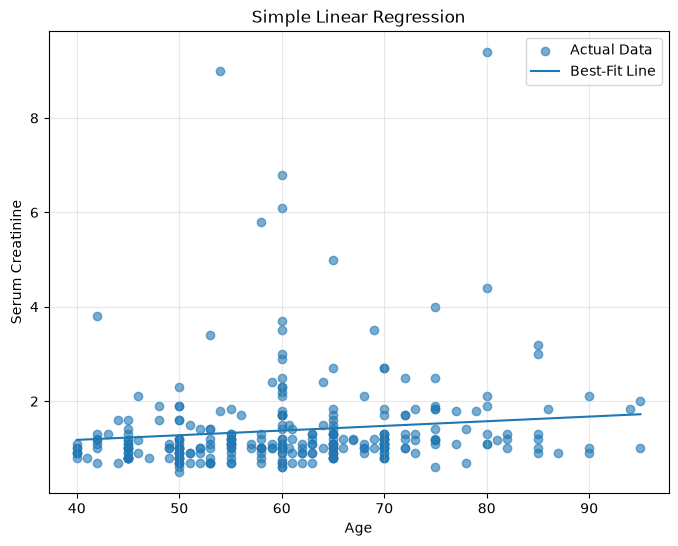

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["age"],
    df["serum_creatinine"],
    alpha=0.6,
    label="Actual Data"
)

age_sorted = np.sort(
    df["age"].values
).reshape(-1, 1)

predicted_line = simple_model.predict(
    age_sorted
)

plt.plot(
    age_sorted,
    predicted_line,
    label="Best-Fit Line"
)

plt.xlabel("Age")
plt.ylabel("Serum Creatinine")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Residuals

Residual is the difference between the actual value and predicted value.

Residual = Actual - Predicted

In [12]:
prediction_results["Residual"] = (
    prediction_results["Actual"]
    - prediction_results["Predicted"]
)

prediction_results.head(10)

,Age,Actual,Predicted,Residual
0,70.0,2.7,1.475704,1.224296
1,50.0,0.9,1.278076,-0.378076
2,45.0,1.1,1.228668,-0.128668
3,80.0,9.4,1.574519,7.825481
4,42.0,1.2,1.199024,0.000976
5,50.0,0.7,1.278076,-0.578076
6,60.0,1.7,1.376890,0.323110
7,45.0,1.3,1.228668,0.071332
8,90.0,2.1,1.673333,0.426667
9,50.0,0.8,1.278076,-0.478076


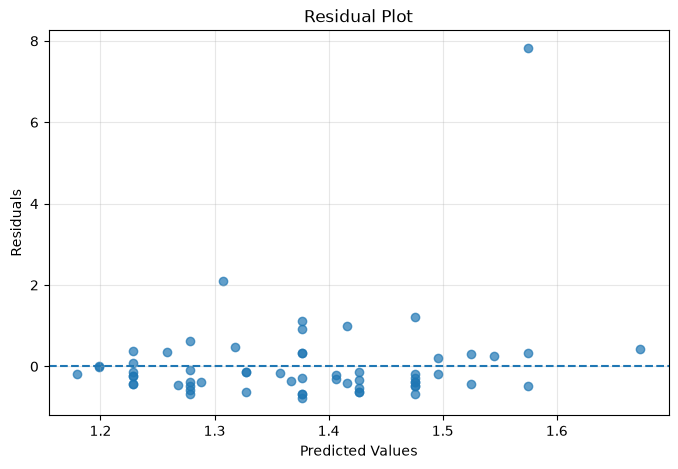

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    prediction_results["Residual"],
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.show()

In [14]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 0.564
RMSE: 1.149
R²  : 0.048


# Multiple Linear Regression

Multiple Linear Regression uses several input features to predict one continuous target.

Target:

`serum_creatinine`

Input Features:

- age
- creatinine_phosphokinase
- ejection_fraction
- platelets
- serum_sodium

In [15]:
multiple_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_sodium"
]

X_multiple = df[multiple_features]

y_multiple = df["serum_creatinine"]

print("X Shape:", X_multiple.shape)
print("y Shape:", y_multiple.shape)

X Shape: (299, 5)
y Shape: (299,)


In [16]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42
)

In [17]:
multiple_model = LinearRegression()

multiple_model.fit(
    X_train_multi,
    y_train_multi
)

print("Multiple Linear Regression Trained")

Multiple Linear Regression Trained


In [18]:
coefficient_table = pd.DataFrame({
    "Feature": multiple_features,
    "Coefficient": multiple_model.coef_
})

coefficient_table

,Feature,Coefficient
0,age,8.757482e-03
1,creatinine_phosphokinase,4.377999e-05
2,ejection_fraction,4.176006e-03
3,platelets,-6.690487e-07
4,serum_sodium,-5.003817e-02


In [19]:
print(
    "Intercept:",
    round(
        multiple_model.intercept_,
        4
    )
)

Intercept: 7.6693


In [20]:
y_pred_multi = multiple_model.predict(
    X_test_multi
)

multi_results = pd.DataFrame({
    "Actual": y_test_multi.values,
    "Predicted": y_pred_multi
})

multi_results.head(10)

,Actual,Predicted
0,2.7,1.635514
1,0.9,1.018824
2,1.1,1.116793
3,9.4,1.606759
4,1.2,1.044695
5,0.7,1.318040
6,1.7,1.410221
7,1.3,0.548202
8,2.1,1.885030
9,0.8,1.113956


In [21]:
multi_mae = mean_absolute_error(
    y_test_multi,
    y_pred_multi
)

multi_mse = mean_squared_error(
    y_test_multi,
    y_pred_multi
)

multi_rmse = np.sqrt(
    multi_mse
)

multi_r2 = r2_score(
    y_test_multi,
    y_pred_multi
)

print("MAE :", round(multi_mae, 3))
print("RMSE:", round(multi_rmse, 3))
print("R²  :", round(multi_r2, 3))

MAE : 0.582
RMSE: 1.172
R²  : 0.01


In [22]:
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae,
        multi_mae
    ],
    "RMSE": [
        rmse,
        multi_rmse
    ],
    "R²": [
        r2,
        multi_r2
    ]
})

model_comparison.round(3)

,Model,MAE,RMSE,R²
0,Simple Linear Regression,0.564,1.149,0.048
1,Multiple Linear Regression,0.582,1.172,0.010


# Manual Prediction

A Simple Linear Regression prediction can also be understood using:

y = mx + b

In [23]:
example_age = 60

manual_prediction = (
    coefficient * example_age
    + intercept
)

model_prediction = simple_model.predict(
    pd.DataFrame({
        "age": [example_age]
    })
)[0]

print(
    "Manual Prediction:",
    round(manual_prediction, 3)
)

print(
    "Model Prediction:",
    round(model_prediction, 3)
)

Manual Prediction: 1.377
Model Prediction: 1.377


In [24]:
print("Original Shape:", df.shape)

print(
    "Original Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Original Columns:",
    df.columns.tolist()
)

Original Shape: (299, 10)
Original Missing Values: 0
Original Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex']


# Summary

In this notebook, we practiced:

## Simple Linear Regression

- Used one feature to predict a continuous target
- Learned a coefficient and intercept
- Created predictions
- Visualized the best-fit line
- Calculated residuals
- Evaluated the model

## Multiple Linear Regression

- Used multiple features
- Learned separate coefficients
- Generated predictions
- Evaluated and compared performance

## Key Learnings

- Linear Regression predicts continuous numerical values.
- Simple Linear Regression uses one input feature.
- Multiple Linear Regression uses multiple input features.
- `fit()` trains the model.
- `predict()` generates predictions.
- Coefficients represent learned linear relationships.
- The intercept is the model's baseline term.
- Residual = Actual - Predicted.
- MAE and RMSE measure prediction error.
- R² compares model performance with a mean-based baseline.
- More features do not automatically guarantee a better model.